In [12]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from aim_resolve import Observation, SignalSpace, SignalModel, plot_arrays, check_type, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

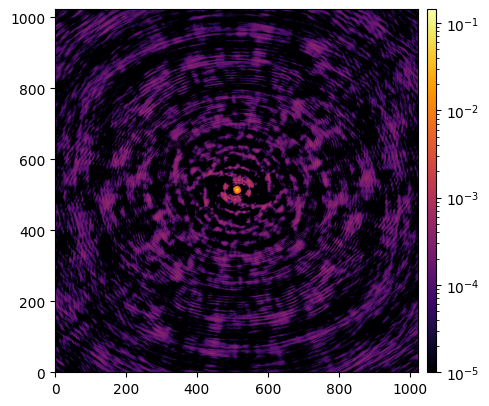

In [13]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100, vmin=1e-5)

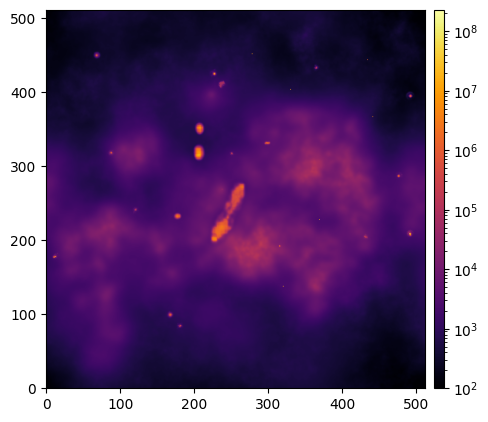

In [14]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_o0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_o1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_o2 = optim_cfg.instantiate_sec('sky_o2.3')
sky_t0 = optim_cfg.instantiate_sec('sky_t0.3')
sky_p0 = optim_cfg.instantiate_sec('sky_p0.3')


with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = samples.mean(sky_bg)
rec_o0 = map_signal(samples.mean(sky_o0), sky_o0.space, sky_bg.space)
rec_o1 = map_signal(samples.mean(sky_o1), sky_o1.space, sky_bg.space)
rec_o2 = map_signal(samples.mean(sky_o2), sky_o2.space, sky_bg.space)
rec_t0 = samples.mean(sky_t0)
rec_p0 = samples.mean(sky_p0)

rec = rec_bg + rec_o0 + rec_o1 + rec_o2 + rec_t0 + rec_p0

plot_arrays(rec, norm='log', vmin=1e2, vmax=rec.max(), dpi=100)

In [15]:
from jax import vmap
from jax.numpy.fft import fftn, ifftn
from jax.lax import dynamic_slice
from jax.scipy.signal import fftconvolve


def build_fft_kernel(kernel, shape, dvol=1.):
    return np.fft.fftn(kernel, shape) * dvol


def build_padder(in_shape, out_shape):
    p0, p1 = [(s - a) for s,a in zip(out_shape, in_shape)]
    return lambda x: jnp.pad(x, ((0, p0), (0, p1)))


def build_slicer(start_indices, out_shape):
    s0, s1 = start_indices
    return lambda x: dynamic_slice(x, (s0, s1), out_shape)


def scipy_fftconvolve(kernel, shape, dvol=1.):
    print('scipy fft shape:', tuple(s+k-1 for s,k in zip(shape, kernel.shape)))
    slicer = build_slicer(tuple(k//2 for k in kernel.shape), shape)
    return lambda x: slicer(fftconvolve(x, kernel, mode='full') * dvol)


def fast_fftconvolve(kernel, shape, dvol=1.):
    fft_kernel = build_fft_kernel(kernel, kernel.shape, dvol)
    fft_kernel = jnp.array(fft_kernel)
    print('fast fft shape:', fft_kernel.shape)

    padder = build_padder(shape, fft_kernel.shape)
    slicer = build_slicer(tuple(k//2 for k in kernel.shape), shape)

    def fun(x):
        x = padder(x)
        r = ifftn(fft_kernel * fftn(x)).real
        r = slicer(r)
        return r

    return fun


def downsample(array, factor):
    return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    

def upsample(array, factor):
    return array.repeat(factor, axis=0).repeat(factor, axis=1)


def build_split_kernel(kernel, shape, size, dvol=1., plot=False):
    fshape = tuple(s+size for s in shape)
    print('split fft shape:', fshape)

    fkernel = np.zeros((2,) +  fshape, dtype='complex128')
    for f in range(1, 3):
        if f == 1:
            slc_in = (slice(0, 0), slice(0, 0))
            slc_out = tuple(slice(k//2 - size//2, k//2 + size//2) for k in kernel.shape)
        else:
            slc_in = slc_out
            slc_out = tuple(slice(0, k) for k in kernel.shape)

        ker = np.array(kernel[slc_out])
        ker[slc_in] = 0

        if plot and f == 1:
            ker1 = ker.copy()
        if f == 2:
            ker = downsample(ker, f)
        
        fker = build_fft_kernel(ker, fshape, dvol * (f**2))
        fkernel[f-1] = fker

    if plot:
        plot_arrays([ker1, ker], label=['kernel (high-res)', 'kernel (low-res)'], rows=1, norm='log', vmin=1e-5, vmax=ker1.max())

    return fkernel


def split_fftconvolve(kernel, shape, size, dvol=1., plot=False):
    fft_kernels = build_split_kernel(kernel, shape, size, dvol, plot)
    fft_kernels = jnp.array(fft_kernels)

    padder1 = build_padder(shape, fft_kernels.shape[1:])
    padder2 = build_padder(tuple(s//2 for s in shape), fft_kernels.shape[1:])
    slicer1 = build_slicer((size//2,) * 2, shape)
    slicer2 = build_slicer(tuple(k//4 for k in kernel.shape), tuple(s//2 for s in shape))

    def fun(x):
        x1 = padder1(x)
        x2 = padder2(downsample(x, 2))
        xx = jnp.stack([x1, x2])
        rr = vmap(lambda ki,xi: ifftn(ki * fftn(xi)).real)(fft_kernels, xx)
        r1 = slicer1(rr[0])
        r2 = upsample(slicer2(rr[1]), 2)
        return r1 + r2

    return fun

scipy fft shape: (1535, 1535)
fast fft shape: (1024, 1024)
split fft shape: (640, 640)


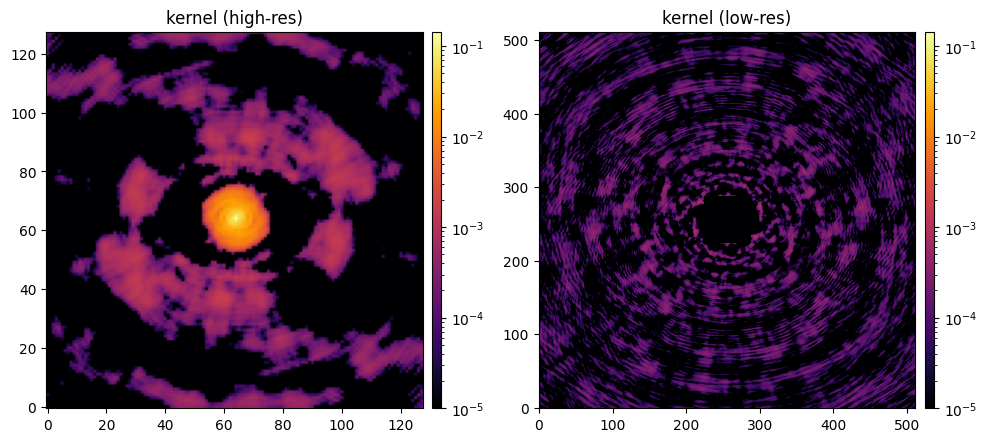

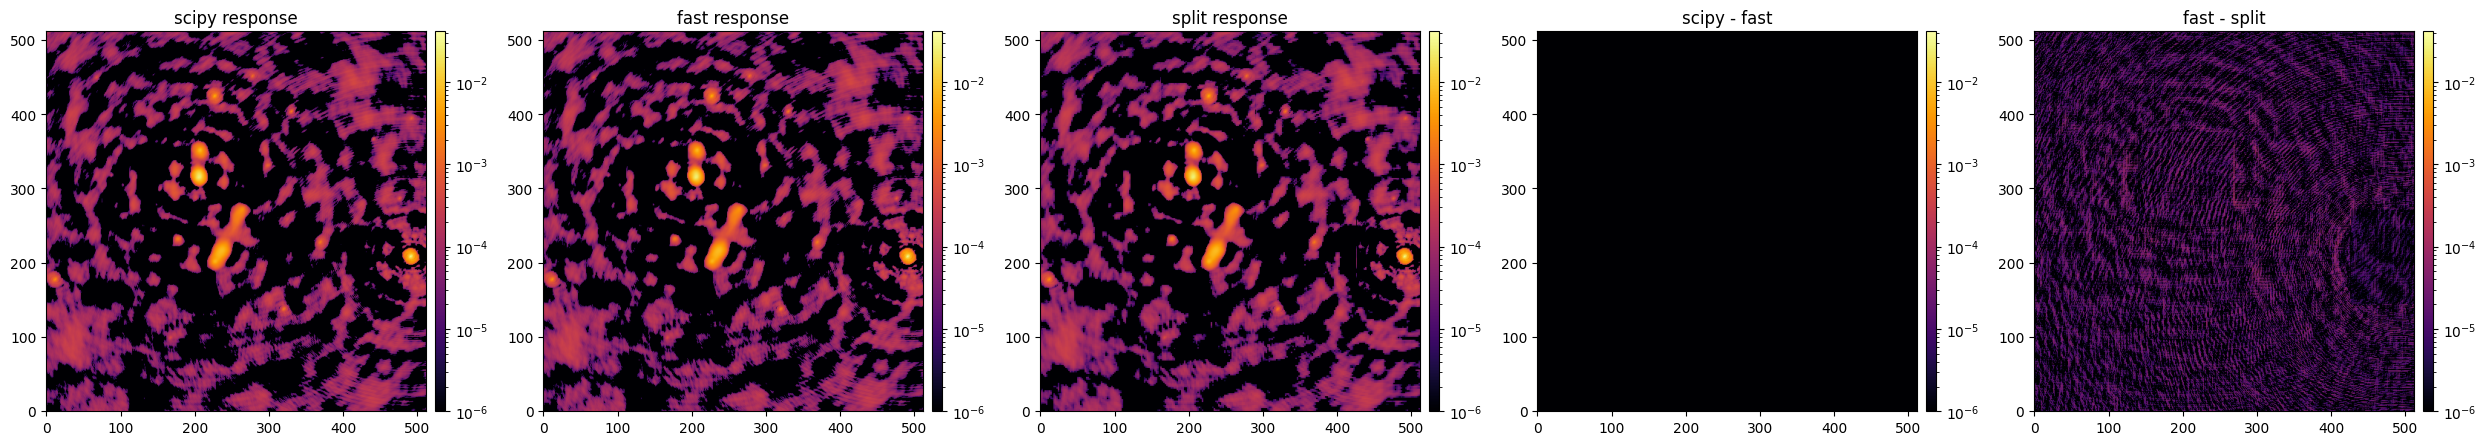

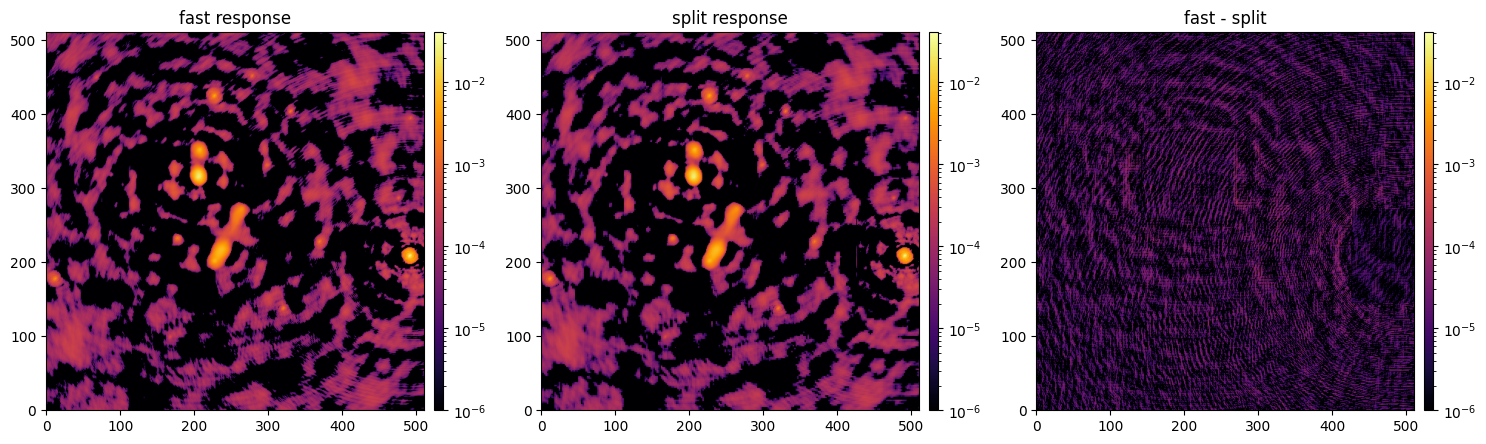

In [16]:
size = 128

scipy_res = scipy_fftconvolve(kernel, rec.shape, space.dis.prod())(rec)
fast_res = fast_fftconvolve(kernel, rec.shape, space.dis.prod())(rec)
split_res = split_fftconvolve(kernel, rec.shape, size, space.dis.prod(), True)(rec)

plot_arrays([scipy_res, fast_res, split_res, scipy_res-fast_res, fast_res-split_res], label=['scipy response', 'fast response', 'split response', 'scipy - fast', 'fast - split'], norm='log', rows=1, vmin=1e-6, vmax=scipy_res.max(), dpi=100)

plot_arrays([fast_res, split_res, fast_res-split_res], label=['fast response', 'split response', 'fast - split'], norm='log', rows=1, vmin=[1e-6]*2, vmax=[scipy_res.max()]*2, dpi=100)

fast fft shape: (1024, 1024)


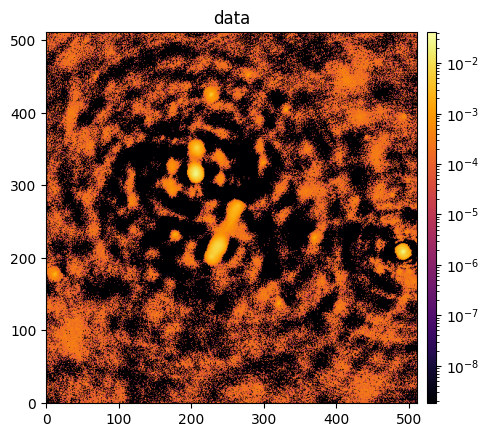

In [17]:
def generate_data(image, kernel, space, n_std=1e-4):
    truth = fast_fftconvolve(kernel, space.shape, space.dis.prod())(image)
    noise = n_std * jax.random.normal(key, truth.shape)
    data = truth + noise
    return data


data = generate_data(rec, kernel, space)

plot_arrays(data, label='data', rows=1, norm='log')

In [18]:
class ScipyResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return scipy_fftconvolve(self.kernel, self.shape, self.dvol)(self.model(x))
    


class FastResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return fast_fftconvolve(self.kernel, self.shape, self.dvol)(self.model(x))



class SplitResponse(jft.Model):
    def __init__(self, model, kernel, size):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.size = size
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return split_fftconvolve(self.kernel, self.shape, self.size, self.dvol)(self.model(x))


scipy fft shape: (1535, 1535)
fast fft shape: (1024, 1024)
split fft shape: (640, 640)
scipy fft shape: (1535, 1535)
fast fft shape: (1024, 1024)
split fft shape: (640, 640)


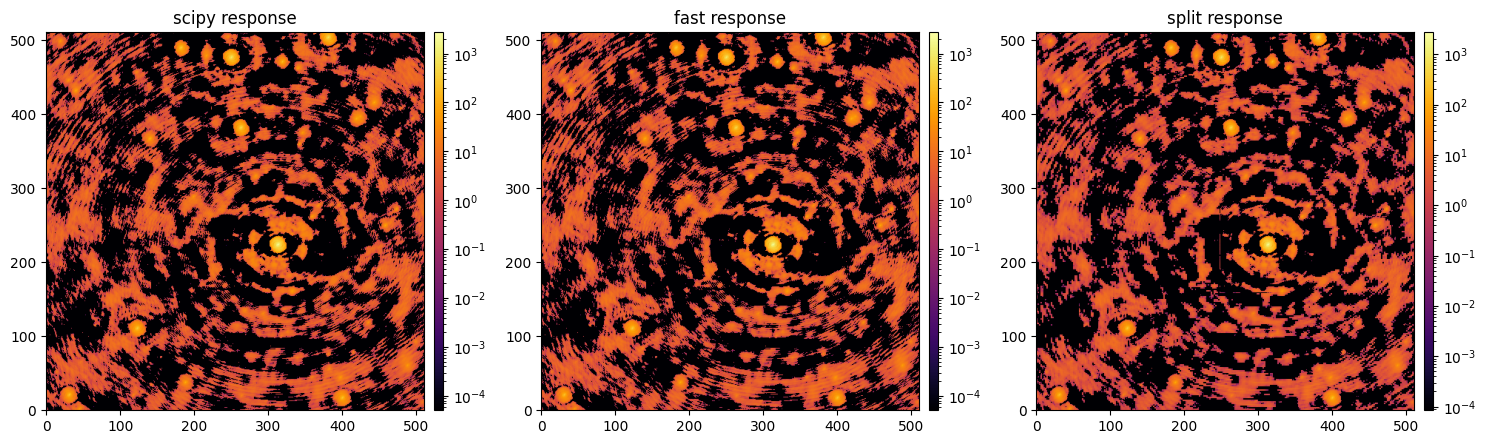

In [19]:
signal = SignalModel.build(
    prefix='sig',
    space=dict(
        shape=(512, 512),
        fov=('2deg', '2deg'),
    ),
    i0=dict(
        offset_mean=12,
        offset_std=(1,1),
        fluctuations=(5,1),
        loglogavgslope=(-2,0.5),
        flexibility=(1.2,0.4),
        asperity=(0.2,0.2),
    ),
)
size = 128

scipy_response = ScipyResponse(signal, kernel)

fast_response = FastResponse(signal, kernel)

split_response = SplitResponse(signal, kernel, size)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

plot_arrays([scipy_response(prior_xi), fast_response(prior_xi), split_response(prior_xi)], label=['scipy response', 'fast response', 'split response'], rows=1, norm='log')

In [25]:
import time

def time_it(fun, image, kernel, **kwargs):
    jit_fun = jax.jit(fun(kernel, image.shape, **kwargs))

    func_compiled = jit_fun.lower(image).compile()

    memory_analysis = func_compiled.memory_analysis()

    start_time = time.time()
    _ = jit_fun(image).block_until_ready()
    elapsed_time = time.time() - start_time
    return elapsed_time, memory_analysis


# Define a random input
N = 2048
shape = (N, N)
size = N//8
print('split shape:', size)

s = jnp.ones(shape)
k = np.ones(tuple(2*s for s in shape))

scipy_time, scipy_memory = time_it(scipy_fftconvolve, s, k, dvol=1.0)
fast_time, fast_memory = time_it(fast_fftconvolve, s, k, dvol=1.0)
split_time, split_memory = time_it(split_fftconvolve, s, k, size=size, dvol=1.0)

print('scipy time:', scipy_time)
print('fast time:', fast_time)
print('split time:', split_time)

print('scipy memory:', scipy_memory)
print('fast memory:', fast_memory)
print('split memory:', split_memory)

split shape: 256
scipy fft shape: (6143, 6143)
fast fft shape: (4096, 4096)
split fft shape: (2304, 2304)
scipy time: 10.983545064926147
fast time: 5.016530752182007
split time: 3.0124709606170654
scipy memory: CompiledMemoryStats(generated_code_size_in_bytes=0, argument_size_in_bytes=33554432, output_size_in_bytes=33554432, alias_size_in_bytes=0, temp_size_in_bytes=905822208, host_generated_code_size_in_bytes=0, host_argument_size_in_bytes=0, host_output_size_in_bytes=0, host_alias_size_in_bytes=0, host_temp_size_in_bytes=0)
fast memory: CompiledMemoryStats(generated_code_size_in_bytes=0, argument_size_in_bytes=33554432, output_size_in_bytes=33554432, alias_size_in_bytes=0, temp_size_in_bytes=536870912, host_generated_code_size_in_bytes=0, host_argument_size_in_bytes=0, host_output_size_in_bytes=0, host_alias_size_in_bytes=0, host_temp_size_in_bytes=0)
split memory: CompiledMemoryStats(generated_code_size_in_bytes=0, argument_size_in_bytes=33554432, output_size_in_bytes=33554432, alia

In [42]:
import matplotlib.pyplot as plt

def memory(fun, image, kernel, **kwargs):
    jit_fun = jax.jit(fun(kernel, image.shape, **kwargs))
    func_compiled = jit_fun.lower(image).compile()
    memory_analysis = func_compiled.memory_analysis()
    return memory_analysis.temp_size_in_bytes


# Define a random input
sizes = 2**np.arange(9, 13)
print('sizes:', sizes)
splits = 2**np.arange(1, 5)
print('splits:', splits)

f_mem, s_mem = [], [[] for _ in splits]
for N in sizes:
    shape = (int(N), int(N))

    s = jnp.ones(shape)
    k = np.ones(tuple(2*s for s in shape))
    fast_memory = memory(fast_fftconvolve, s, k, dvol=1.0)
    f_mem.append(fast_memory)

    for i,K in enumerate(splits):
        size = int(N//K)
        split_memory = memory(split_fftconvolve, s, k, size=size, dvol=1.0)
        s_mem[i].append(split_memory)

print('fast memory:', f_mem)
print('split memory:', s_mem)

sizes: [ 512 1024 2048 4096]
splits: [ 2  4  8 16]
fast fft shape: (1024, 1024)
split fft shape: (768, 768)
split fft shape: (640, 640)
split fft shape: (576, 576)
split fft shape: (544, 544)
fast fft shape: (2048, 2048)
split fft shape: (1536, 1536)
split fft shape: (1280, 1280)
split fft shape: (1152, 1152)
split fft shape: (1088, 1088)
fast fft shape: (4096, 4096)
split fft shape: (3072, 3072)
split fft shape: (2560, 2560)
split fft shape: (2304, 2304)
split fft shape: (2176, 2176)
fast fft shape: (8192, 8192)
split fft shape: (6144, 6144)
split fft shape: (5120, 5120)
split fft shape: (4608, 4608)
split fft shape: (4352, 4352)
fast memory: [33554432, 134217728, 536870912, 2147483648]
split memory: [[37748736, 150994944, 603979776, 2415919104], [26214400, 104857600, 419430400, 1677721600], [21233664, 84934656, 339738624, 1358954496], [18939904, 75759616, 303038464, 1212153856]]


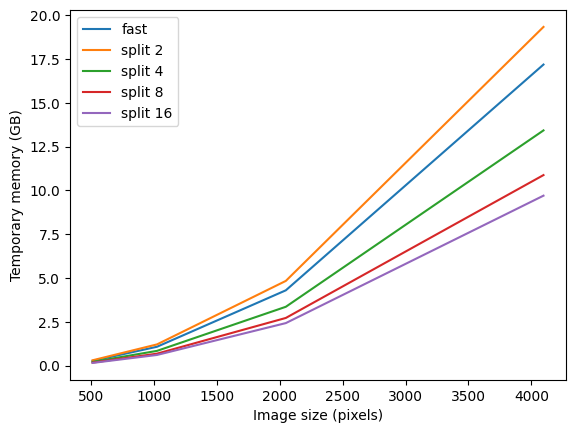

In [44]:

plt.plot(sizes, np.array(f_mem)*8/1e9, label='fast')
for i, K in enumerate(splits):
    plt.plot(sizes, np.array(s_mem[i])*8/1e9, label=f'split {K}')
plt.legend()
plt.ylabel('Temporary memory (GB)')
plt.xlabel('Image size (pixels)')
plt.show()

In [51]:
print(536870912*8/1e9)
print(339738624*8/1e9)

4.294967296
2.717908992


OPTIMIZE_KL: Starting 0001


s == p == set()
fast fft shape: (1024, 1024)
fast fft shape: (1024, 1024)
fast fft shape: (1024, 1024)
fast fft shape: (1024, 1024)


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3167e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.016±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²:   2e-05±     0.0, avg:  +0.0045±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:  0.0031±     0.0, avg:   +0.055±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     5.6±     0.0, avg:     +2.4±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.18±     0.0, avg:    +0.43±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00025±     0.0, avg: +1.5e-06±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     2.0±     0.0, avg:     +1.4±     0.0, #dof:      1'




fast fft shape: (1024, 1024)


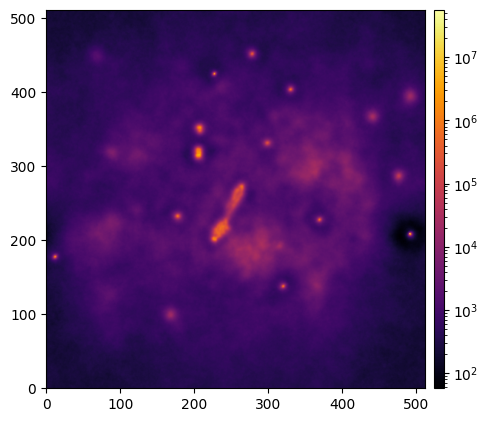

In [ ]:
lh_dct = dict(
    data = data,
    model = fast_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

fast_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()
split fft shape: (640, 640)
split fft shape: (640, 640)
split fft shape: (640, 640)
split fft shape: (640, 640)


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3782e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:   +0.019±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²:   4e-05±     0.0, avg:  +0.0063±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:  0.0045±     0.0, avg:   +0.067±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     5.7±     0.0, avg:     +2.4±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.19±     0.0, avg:    +0.43±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00012±     0.0, avg:  -0.0016±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00025±     0.0, avg: +5.3e-07±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     2.0±     0.0, avg:     +1.4±     0.0, #dof:      1'




split fft shape: (640, 640)


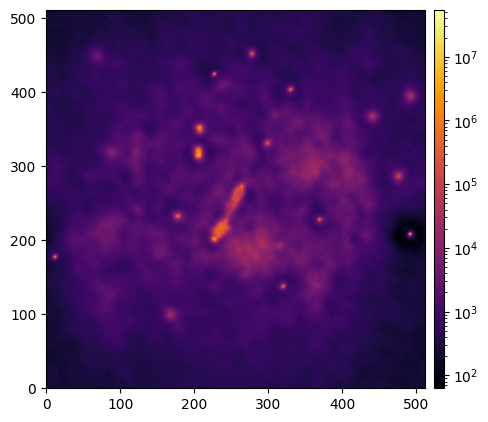

In [50]:
lh_dct = dict(
    data = data,
    model = split_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

split_samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

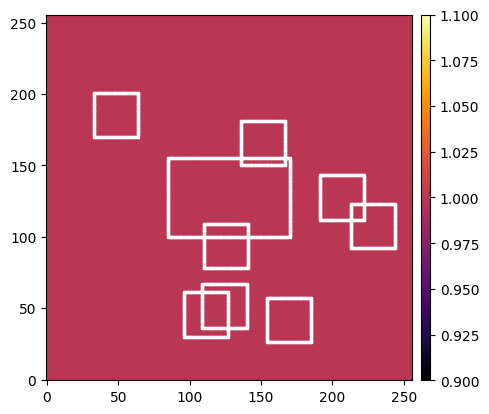

In [40]:
from aim_resolve import SignalGrid, yaml_load, plot_arrays, map_signal

dct = yaml_load('mdl.yml')

grid = SignalGrid.build(space=(256,256))

def draw_boxes(cfg_sections, grid, it):
    box_map = np.zeros(grid.shape)

    for k,v in cfg_sections.items():
        if 'sky_t' in k and f'.{it}' in k:
            si = SignalGrid.build(**v['tile_grid'])
            xi = np.ones((si.n_copies,)+si.shape)
            fi = si.factor
            xi[:, fi:-fi, fi:-fi] = 0
            box_map += map_signal(si, grid)(xi)
        elif 'sky_o' in k and f'.{it}' in k:
            si = SignalGrid.build(**v['grid'])
            xi = np.ones(si.shape)
            fi = si.factor
            xi[fi:-fi, fi:-fi] = 0
            box_map += map_signal(si, grid)(xi)
    
    return box_map.clip(0,1)


box_map = draw_boxes(dct, grid, 1)
ox, oy = np.argwhere(box_map == 1).T
oj_mrk = dict(x=ox, y=oy, s=1, c='white', marker=',')
plot_arrays(
    array = np.ones(grid.shape), 
    marker = dict(oj_mrk=oj_mrk),
)


In [ ]:
class PointGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, coordinates, factor=1, n_copies=1):
        check_type(coordinates, tuple, (tuple, float), float)
        check_type(factor, int)
        check_type(n_copies, int)

        self.shape = (1, 1)
        self.coordinates = coordinates
        self.factor = factor
        self.n_copies = n_copies

    def __repr__(self):
        return f'PointGrid(coordinates={self.coordinates}, factor={self.factor}, n_copies={self.n_copies})'
    
    @classmethod
    def build(cls, *, coordinates, factor=1, n_copies=1):
        '''
        Build a PointSpace object from the given parameters.
        
        Parameters
        ----------
        coordinates : float or tuple
            The coordinates of the point sources
        n_copies : int, optional
            The number of point sources, by default 1
        '''
        n_c = to_shape(n_copies, (), 'int64')
        if not is_val(n_c):
            n_c = 1
        n_copies = int(n_c)

        fac = to_shape(factor, (), 'int64')
        if not is_val(fac):
            fac = 1
        factor = int(fac)

        coos = to_shape(coordinates, (n_copies, 2), 'float64')
        grid = np.linspace(1/(2*factor), 1 - 1/(2*factor), factor)
        if not np.all(np.isin(coos % 1, grid)):
            raise ValueError(f'For a factor of {factor}, coordinates % 1 must be in {grid}.')
        coordinates = tuple(map(tuple, coos.tolist()))
        if n_copies == 1:
            coordinates = coordinates[0]

            
        return cls(coordinates, factor, n_copies)

    @property
    def coos(self):
        return np.array(self.coordinates)
    
    @property
    def shp(self):
        return np.array(self.shape)
    
    @property
    def fac(self):
        return np.array(self.factor)
    
    @property
    def ndim(self):
        return len(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def lims(self):
        return self.coos.reshape(-1, 2)[:,:,None].repeat(2, axis=-1)
    
    def refine(self, factor):
        offsets = np.array([[-1, -1], [-1,  1], [ 1, -1], [ 1,  1]]) / (2 * self.fac * factor)
        coos = self.coos[None, :, :] + offsets[:, None, :]
        coos = coos.reshape(-1, 2)
        order = np.concatenate([np.arange(i, coos.shape[0], 2) for i in range(2)])
        coos = coos[order]
        return PointGrid(tuple(map(tuple, coos.tolist())), self.factor * factor, self.n_copies * factor**2)
    
    def update(self, **kwargs):
        dct = self.to_dict()
        dct.update(kwargs)
        return PointGrid.build(**dct)

    def to_dict(self):
        '''Convert the grid to a dictionary ({coordinates: [[cx,cy], ...], ...}).'''
        dct = {'coordinates': self.coos.tolist()}
        if self.factor != 1:
            dct['factor'] = int(self.factor)
        if self.n_copies != 1:
            dct['n_copies'] = int(self.n_copies)
        return dct
    

pg = PointGrid.build(coordinates=[[-0.5,-0.5],[1.5,1.5]], n_copies=2)
print(pg)

pg = pg.refine(factor=2)
print(pg)

PointGrid(coordinates=((-0.5, -0.5), (1.5, 1.5)), factor=1, n_copies=2)
[[-0.75 -0.75]
 [ 1.25  1.25]
 [-0.75 -0.25]
 [ 1.25  1.75]
 [-0.25 -0.75]
 [ 1.75  1.25]
 [-0.25 -0.25]
 [ 1.75  1.75]]
[[-0.75 -0.75]
 [-0.75 -0.25]
 [-0.25 -0.75]
 [-0.25 -0.25]
 [ 1.25  1.25]
 [ 1.25  1.75]
 [ 1.75  1.25]
 [ 1.75  1.75]]
PointGrid(coordinates=((-0.75, -0.75), (-0.75, -0.25), (-0.25, -0.75), (-0.25, -0.25), (1.25, 1.25), (1.25, 1.75), (1.75, 1.25), (1.75, 1.75)), factor=2, n_copies=8)


In [74]:
n = 8
a = np.concatenate([np.arange(i, n, 2) for i in range(2)])
print(a)

[0 2 4 6 1 3 5 7]


In [77]:
a = np.array([[1,1],[2,2]])
print(a)
b = a.repeat(4, axis=0)
print(b)

[[1 1]
 [2 2]]
[[1 1]
 [1 1]
 [1 1]
 [1 1]
 [2 2]
 [2 2]
 [2 2]
 [2 2]]
